In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import joblib
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models

import warnings
warnings.filterwarnings('ignore')

In [2]:
X = joblib.load('diff_images_after_compress_2_increase_ds.joblib')
actual_images = joblib.load('actual_images_after_compress_2_increase_ds.joblib')
expected_images = joblib.load('expected_images_after_compress_2_increase_ds.joblib') 
y = joblib.load('y_labels_2_increase_ds.joblib')


X = np.array(X, dtype=object)  
actual_images = np.array(actual_images, dtype=object)
expected_images = np.array(expected_images, dtype=object)
y = np.array(y)

subtype_labels = []
for i in range(len(X)):
    if i < 200:
        subtype_labels.append('disappeared')
    elif i < 250:
        subtype_labels.append('color_change')
    elif i < 400:
        subtype_labels.append('shift')
    elif i < 500:
        subtype_labels.append('dynamic')
    else:
        subtype_labels.append('banner')

subtype_labels = np.array(subtype_labels)

In [3]:
class LightCNNDiffClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(LightCNNDiffClassifier, self).__init__()
        
        self.features = nn.Sequential(
            # Первый свёрточный блок: 224 -> 112
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Второй свёрточный блок: 112 -> 56
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Третий свёрточный блок: 56 -> 28
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Четвёртый свёрточный блок: 28 -> 14
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((7, 7)),  # Приводим к фиксированному размеру 7x7
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Train: 457, Val: 115, Test: 246
Using device: cpu

Epoch 1/30


Validation: 100%|█████████████████████████████████| 8/8 [00:03<00:00,  2.18it/s]


Train Loss: 0.6850, Train Acc: 66.96%
Val Loss: 0.4820, Val Acc: 77.39%
Model saved with Val Acc: 77.39%

Epoch 2/30


Validation: 100%|█████████████████████████████████| 8/8 [00:03<00:00,  2.17it/s]


Train Loss: 0.3615, Train Acc: 86.43%
Val Loss: 0.2724, Val Acc: 86.96%
Model saved with Val Acc: 86.96%

Epoch 3/30


...

Train Loss: 0.0116, Train Acc: 99.78%
Val Loss: 0.0709, Val Acc: 98.26%

Epoch 30/30


Validation: 100%|█████████████████████████████████| 8/8 [00:03<00:00,  2.23it/s]


Train Loss: 0.0075, Train Acc: 99.78%
Val Loss: 0.0720, Val Acc: 98.26%


Validation: 100%|███████████████████████████████| 16/16 [00:07<00:00,  2.09it/s]



Test Loss: 0.0342, Test Acc: 99.19%

Classification Report:
              precision    recall  f1-score   support

     Not Bug       0.98      1.00      0.99       126
         Bug       1.00      0.98      0.99       120

    accuracy                           0.99       246
   macro avg       0.99      0.99      0.99       246
weighted avg       0.99      0.99      0.99       246



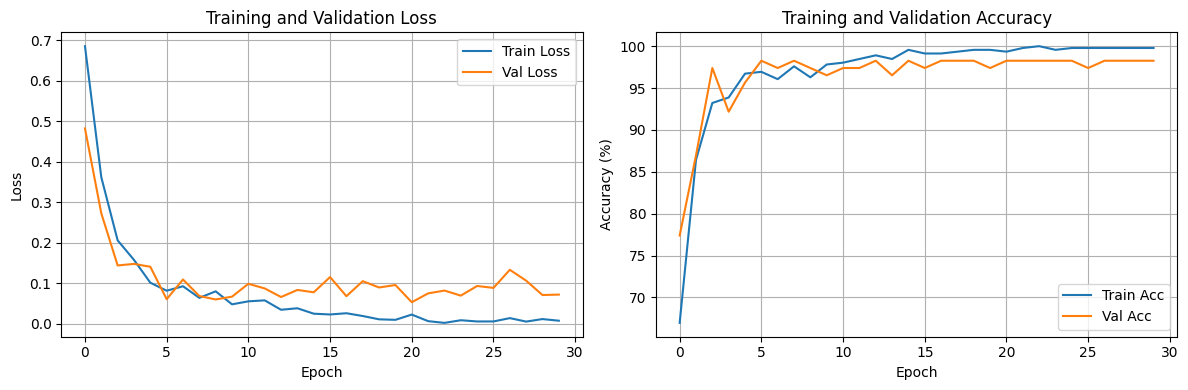

In [4]:
class ThreeChannelDiffDataset(Dataset):
    def __init__(self, expected_images, actual_images, diff_images, labels, transform=None):
        self.expected_images = expected_images
        self.actual_images = actual_images
        self.diff_images = diff_images
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        expected = self.expected_images[idx]
        actual = self.actual_images[idx]
        diff = self.diff_images[idx]
        
        # Приводим все к 2D
        def to_2d(img):
            if len(img.shape) == 3:
                if img.shape[-1] == 3:
                    return np.mean(img, axis=-1)
                else:
                    return img[:, :, 0]
            return img
        
        expected = to_2d(expected)
        actual = to_2d(actual)
        diff = to_2d(diff)
        
        # Комбинируем три изображения в трехканальное
        # Каждое изображение становится отдельным каналом
        combined = np.stack([expected, actual, diff], axis=-1)
        
        if combined.dtype != np.uint8:
            if combined.max() <= 1.0:
                combined = (combined * 255).astype(np.uint8)
            else:
                combined = combined.astype(np.uint8)
        
        # Создаем RGB изображение
        img = Image.fromarray(combined, mode='RGB')
        
        if self.transform:
            img = self.transform(img)
        
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label
        

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])


def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(dataloader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels


def train_model(X, y, subtype_labels, expected_images, actual_images,
                num_epochs=30, 
                batch_size=16, 
                learning_rate=0.001):
    
    original_indixes = np.arange(len(X))
    
    X_train, X_test, y_train, y_test, sub_train, sub_test, idx_train, idx_test = train_test_split(
        X, y, subtype_labels, original_indixes,
        test_size=0.3,
        stratify=subtype_labels,
        random_state=69
    )
    
    exp_train, exp_test = expected_images[idx_train], expected_images[idx_test]
    act_train, act_test = actual_images[idx_train], actual_images[idx_test]
    
    X_train, X_val, y_train, y_val, exp_train, exp_val, act_train, act_val = train_test_split(
        X_train, y_train, exp_train, act_train,
        test_size=0.2, 
        stratify=y_train, 
        random_state=69
    )
    
    print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
    
    train_dataset = ThreeChannelDiffDataset(
        expected_images=exp_train,
        actual_images=act_train,
        diff_images=X_train,
        labels=y_train,
        transform=train_transform
    )
    
    val_dataset = ThreeChannelDiffDataset(
        expected_images=exp_val,
        actual_images=act_val,
        diff_images=X_val,
        labels=y_val,
        transform=val_transform
    )
    
    test_dataset = ThreeChannelDiffDataset(
        expected_images=exp_test,
        actual_images=act_test,
        diff_images=X_test,
        labels=y_test,
        transform=val_transform
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    model = LightCNNDiffClassifier(num_classes=2)
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        val_loss, val_acc, _, _ = validate_epoch(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        scheduler.step(val_loss)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"Model saved with Val Acc: {val_acc:.2f}%")
    
    model.load_state_dict(torch.load('best_model.pth'))
    
    test_loss, test_acc, test_preds, test_labels = validate_epoch(
        model, test_loader, criterion, device
    )
    
    print(f"\n{'='*60}")
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    print(f"\nClassification Report:")
    print(classification_report(test_labels, test_preds, target_names=['Not Bug', 'Bug']))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(train_accs, label='Train Acc')
    ax2.plot(val_accs, label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=100)
    plt.show()
    
    return model, test_preds, test_labels, idx_test, test_loader, device
    

model, test_preds, test_labels, idx_test, test_loader, device = train_model(
    X=X,
    y=y,
    subtype_labels=subtype_labels,
    expected_images=expected_images,
    actual_images=actual_images,
    num_epochs=30,
    batch_size=16,
    learning_rate=0.001
)

In [5]:
test_preds_array = np.array(test_preds)
test_labels_array = np.array(test_labels)

error_indexes = np.where(test_preds_array != test_labels_array)[0]

print(f"Number of errors: {len(error_indexes)}")
print(f"Error indices in test set: {error_indexes}")

false_positives = np.where((test_preds_array == 1) & (test_labels_array == 0))[0]
false_negatives = np.where((test_preds_array == 0) & (test_labels_array == 1))[0]

print(f"False Positives (FP): {len(false_positives)}, indices: {false_positives}")
print(f"False Negatives (FN): {len(false_negatives)}, indices: {false_negatives}")

Number of errors: 2
Error indices in test set: [ 52 104]
False Positives (FP): 0, indices: []
False Negatives (FN): 2, indices: [ 52 104]


Индексы с ошибками [357 239]


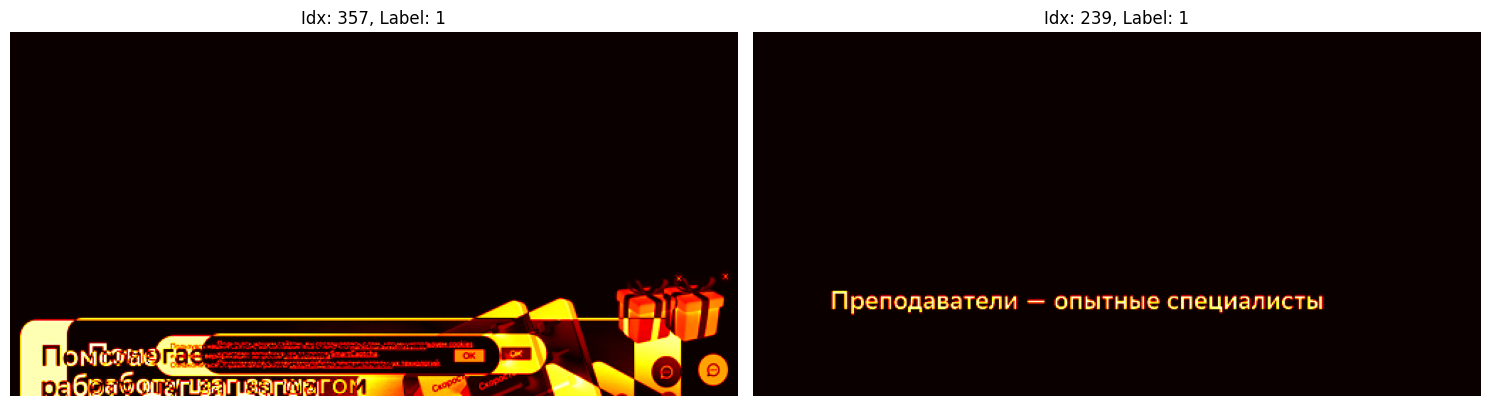

In [7]:
incorrect_original_indixes = idx_test[error_indexes]
print(f"Индексы с ошибками {incorrect_original_indixes}")
X = joblib.load('diff_images_after_compress_2_increase_ds.joblib')


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_original_indixes):
        idx = incorrect_original_indixes[i]
        if idx < len(X):
            ax.imshow(X[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
def analyze_predictions_by_subtype(model, test_loader, device, idx_test, subtype_labels, y_test):
    """
    Анализирует ошибки модели по типам (подтипам) изображений
    """
    model.eval()
    
    all_preds = []
    all_labels = []
    all_indices = []
    
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(test_loader):
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            # Получаем индексы для этого батча
            start_idx = batch_idx * test_loader.batch_size
            end_idx = min(start_idx + test_loader.batch_size, len(idx_test))
            batch_indices = idx_test[start_idx:end_idx]
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_indices.extend(batch_indices)
    
    results_df = pd.DataFrame({
        'idx': all_indices,
        'true_label': all_labels,
        'pred_label': all_preds,
        'subtype': [subtype_labels[idx] for idx in all_indices]
    })
    
    results_df['is_error'] = results_df['true_label'] != results_df['pred_label']
    
    print("="*80)
    print("АНАЛИЗ ОШИБОК ПО ТИПАМ ИЗОБРАЖЕНИЙ")
    print("="*80)
    
    subtype_stats = results_df.groupby('subtype').agg({
        'idx': 'count',
        'is_error': ['sum', 'mean'],
        'true_label': lambda x: (x == 1).sum()  # количество багов
    }).round(3)
    
    subtype_stats.columns = ['total_samples', 'errors_count', 'error_rate', 'bug_count']
    subtype_stats['accuracy'] = 1 - subtype_stats['error_rate']
    
    print("\nСТАТИСТИКА ПО ТИПАМ:")
    print(subtype_stats)
    
    print("\n" + "="*80)
    print("MATRIX ОШИБОК ДЛЯ КАЖДОГО ТИПА:")
    print("="*80)
    
    subtype_confusion = {}
    for subtype in results_df['subtype'].unique():
        subtype_data = results_df[results_df['subtype'] == subtype]
        
        unique_true = subtype_data['true_label'].unique()
        unique_pred = subtype_data['pred_label'].unique()
        all_classes = sorted(set(unique_true) | set(unique_pred))
        
        if len(all_classes) == 1:
            print(f"\n{subtype}:")
            print(f"  Only class {all_classes[0]} present in this subtype")
            print(f"  All predictions are correct? {len(subtype_data[subtype_data['is_error']]) == 0}")
            
            only_class = all_classes[0]
            if only_class == 0:
                cm = np.array([[len(subtype_data), 0], 
                               [0, 0]])
            else:
                cm = np.array([[0, 0], 
                               [0, len(subtype_data)]])
            subtype_confusion[subtype] = cm
            
            print(f"Confusion Matrix:")
            print(cm)
            print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
            print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")
            
            tn, fp, fn, tp = cm.ravel()
            accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            print(f"Accuracy: {accuracy:.3f}")
            print(f"Precision: {precision:.3f} (only one class present)")
            print(f"Recall: {recall:.3f} (only one class present)")
            print(f"F1-Score: {f1:.3f} (only one class present)")
            
        else:
            cm = confusion_matrix(subtype_data['true_label'], subtype_data['pred_label'], 
                                 labels=[0, 1])
            subtype_confusion[subtype] = cm
            
            print(f"\n{subtype}:")
            print(f"Confusion Matrix:")
            print(cm)
            print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
            print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")
            
            tn, fp, fn, tp = cm.ravel()
            accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            print(f"Accuracy: {accuracy:.3f}")
            print(f"Precision: {precision:.3f}")
            print(f"Recall: {recall:.3f}")
            print(f"F1-Score: {f1:.3f}")
    
    return results_df, subtype_stats, subtype_confusion

def plot_subtype_analysis(results_df, subtype_stats):
    """
    Визуализация ошибок по подтипам
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    ax1 = axes[0, 0]
    subtype_stats_sorted = subtype_stats.sort_values('error_rate', ascending=False)
    colors = ['red' if x > 0.3 else 'orange' if x > 0.15 else 'green' 
              for x in subtype_stats_sorted['error_rate']]
    ax1.bar(subtype_stats_sorted.index, subtype_stats_sorted['error_rate'] * 100, 
            color=colors, alpha=0.7)
    ax1.set_title('Error Rate by Subtype', fontsize=14)
    ax1.set_xlabel('Subtype')
    ax1.set_ylabel('Error Rate (%)')
    ax1.axhline(y=15, color='orange', linestyle='--', label='Warning threshold (15%)')
    ax1.axhline(y=30, color='red', linestyle='--', label='Critical threshold (30%)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[0, 1]
    ax2.bar(subtype_stats.index, subtype_stats['total_samples'], alpha=0.7, color='skyblue')
    ax2.set_title('Number of Samples by Subtype', fontsize=14)
    ax2.set_xlabel('Subtype')
    ax2.set_ylabel('Count')
    ax2.grid(True, alpha=0.3)
    
    ax3 = axes[0, 2]
    ax3.bar(subtype_stats.index, subtype_stats['accuracy'] * 100, alpha=0.7, color='lightgreen')
    ax3.set_title('Accuracy by Subtype', fontsize=14)
    ax3.set_xlabel('Subtype')
    ax3.set_ylabel('Accuracy (%)')
    ax3.axhline(y=85, color='green', linestyle='--', label='Good (85%)')
    ax3.set_ylim([0, 100])
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    ax4 = axes[1, 0]
    error_counts = results_df.groupby(['subtype', 'is_error']).size().unstack(fill_value=0)
    if 'False' not in error_counts.columns:
        error_counts['False'] = 0
    if 'True' not in error_counts.columns:
        error_counts['True'] = 0
    error_counts = error_counts[['False', 'True']]
    error_counts.columns = ['Correct', 'Wrong']
    error_counts.plot(kind='bar', stacked=True, ax=ax4, color=['green', 'red'], alpha=0.7)
    ax4.set_title('Correct vs Wrong Predictions by Subtype', fontsize=14)
    ax4.set_xlabel('Subtype')
    ax4.set_ylabel('Count')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    ax5 = axes[1, 1]
    error_dist = results_df[results_df['is_error']]['subtype'].value_counts()
    if len(error_dist) > 0:
        ax5.pie(error_dist.values, labels=error_dist.index, autopct='%1.1f%%', 
                startangle=90, colors=plt.cm.Set3(range(len(error_dist))))
        ax5.set_title('Error Distribution by Subtype', fontsize=14)
    else:
        ax5.text(0.5, 0.5, 'No errors!', 
                transform=ax5.transAxes, fontsize=14, ha='center', va='center')
        ax5.set_title('Error Distribution by Subtype', fontsize=14)
    
    ax6 = axes[1, 2]
    ax6.text(0.1, 0.5, 
             f"Total samples: {len(results_df)}\n"
             f"Total errors: {results_df['is_error'].sum()}\n"
             f"Overall error rate: {results_df['is_error'].mean():.2%}\n"
             f"Best subtype: {subtype_stats['accuracy'].idxmax()} ({subtype_stats['accuracy'].max():.2%})\n"
             f"Worst subtype: {subtype_stats['accuracy'].idxmin()} ({subtype_stats['accuracy'].min():.2%})",
             transform=ax6.transAxes, fontsize=12, verticalalignment='center')
    ax6.set_title('Summary Statistics', fontsize=14)
    ax6.axis('off')
    
    plt.tight_layout()
    plt.savefig('subtype_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

In [9]:
results_df, subtype_stats, subtype_confusion = analyze_predictions_by_subtype(
    model=model,
    test_loader=test_loader,
    device=device,
    idx_test=idx_test,
    subtype_labels=subtype_labels,
    y_test=y
)

АНАЛИЗ ОШИБОК ПО ТИПАМ ИЗОБРАЖЕНИЙ

СТАТИСТИКА ПО ТИПАМ:
              total_samples  errors_count  error_rate  bug_count  accuracy
subtype                                                                   
banner                   96             0       0.000          0     1.000
color_change             15             1       0.067         15     0.933
disappeared              60             0       0.000         60     1.000
dynamic                  30             0       0.000          0     1.000
shift                    45             1       0.022         45     0.978

MATRIX ОШИБОК ДЛЯ КАЖДОГО ТИПА:

banner:
  Only class 0 present in this subtype
  All predictions are correct? True
Confusion Matrix:
[[96  0]
 [ 0  0]]
True Negatives: 96, False Positives: 0
False Negatives: 0, True Positives: 0
Accuracy: 1.000
Precision: 0.000 (only one class present)
Recall: 0.000 (only one class present)
F1-Score: 0.000 (only one class present)

color_change:
Confusion Matrix:
[[ 0  0]
 [ 1 14

### Выводы
Модель с меньшим количеством параметров не переобучилась и показала отличный результат! Но она намного сложнее в реализации и требует больше ресурсов.

In [13]:
X_other = joblib.load('diff_images_after_compress_5_other_domain.joblib')
act_other = joblib.load('actual_images_after_compress_5_other_domain.joblib')
exp_other = joblib.load('expected_images_after_compress_5_other_domain.joblib') 
y_other = joblib.load('y_labels_5_other_domain.joblib')


X_other = np.array(X_other, dtype=object)  
act_other = np.array(act_other, dtype=object)
exp_other = np.array(exp_other, dtype=object)
y_other = np.array(y_other)

subtype_labels = []
for i in range(len(X_other)):
    if i < 20:
        subtype_labels.append('disappeared')
    elif i < 40:
        subtype_labels.append('color_change')
    elif i < 70:
        subtype_labels.append('shift')
    elif i < 88:
        subtype_labels.append('dynamic')
    else:
        subtype_labels.append('banner')

subtype_labels = np.array(subtype_labels)

In [16]:
other_dataset = ThreeChannelDiffDataset(
    expected_images=exp_other,
    actual_images=act_other,
    diff_images=X_other,
    labels=y_other,
    transform=val_transform
)
other_loader = DataLoader(other_dataset, batch_size=16, shuffle=False)

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in other_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Accuracy на внешнем домене: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, target_names=['Not Bug', 'Bug']))

Accuracy на внешнем домене: 0.6273
              precision    recall  f1-score   support

     Not Bug       0.49      0.65      0.56        40
         Bug       0.75      0.61      0.68        70

    accuracy                           0.63       110
   macro avg       0.62      0.63      0.62       110
weighted avg       0.66      0.63      0.63       110



### Выводы
Нейросеть выучив один домен, оказалась бесполезной на другом домене. А вот классические модели с математическими признаками показали результат на другом домене намного лучше! А учитывая, что в web приложении может появиться ещё одна страница с другим дизайном - это критично. Так как для нейросети потребует переобучения и накопления данных для него, а классическая модель просто будет работать чуть хуже, но справится со своей задачей. А время, деньги и скорость крайне важны!